# Estimator comparison

Produces Figure 5.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("estimator_comparison")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.figstyle import (CATEGORICAL, DASHES, PALETTE, PT, figure,
                          panel_label, save_figure, share_y,
                          threshold_line, use_manuscript_style)

use_manuscript_style()


Wrote figures/fig5_estimator_comparison.pdf


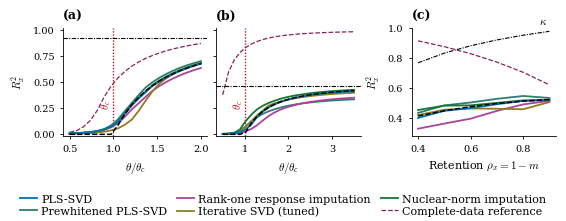

moderate_retention: mean imputation departs from the zero-filled estimator by at most 0.0039
low_retention: mean imputation departs from the zero-filled estimator by at most 0.0024
retention_sweep: mean imputation departs from the zero-filled estimator by at most 0.0011


In [3]:
SHOWN = {
    'pls':          (PALETTE['x'],        '-',  'PLS-SVD'),
    'pls_prewhite': (CATEGORICAL[0],      '-',  'Prewhitened PLS-SVD'),
    'em_pls':       (CATEGORICAL[1],      '-',  'Rank-one response imputation'),
    'iter_svd':     (CATEGORICAL[2],      '-',  'Iterative SVD (tuned)'),
    'soft_impute':  (CATEGORICAL[5],      '-',  'Nuclear-norm imputation'),
    'oracle':       (PALETTE['complete'], '--', 'Complete-data reference'),
}
HEIGHT_PT = 146.0

fig, axes = figure(HEIGHT_PT, 3)
fig.get_layout_engine().set(h_pad=0.015, w_pad=0.02, hspace=0.02)

def draw(ax, xs, block, order):
    """Draw one estimator-comparison panel."""
    for name, (color, ls, label) in SHOWN.items():
        mean = np.asarray([r[f'Rx2_{name}_mean'] for r in block['results']])[order]
        ref = name == 'oracle'
        ax.plot(xs, mean, ls, lw=0.9 if ref else 1.3, color=color,
                zorder=2 if ref else (6 if name == 'pls' else 4),
                label=label if ax is axes[0] else None)
    return ax

for ax, cfg, letter in ((axes[0], 'moderate_retention', '(a)'), (axes[1], 'low_retention', '(b)')):
    block = results[cfg]
    xs = np.asarray(block['theta_values']) / block['theta_c']
    draw(ax, xs, block, np.arange(len(xs)))
    ax.plot(xs, block['theory_Rx2'], color=PALETTE['theory'], lw=1.1,
            ls=DASHES['theory_alt'], zorder=7)
    ax.axhline(block['kappa'], color=PALETTE['ceiling'], lw=0.8,
               ls=DASHES['ceiling'], zorder=3)
    threshold_line(ax, 1.0, r'$\theta_c$', y=0.30)
    ax.set_xlabel(r'$\theta/\theta_c$')
    panel_label(ax, letter)

retention = results['retention_sweep']
rho_x = np.asarray([1.0 - r['m'] for r in retention['results']])
order = np.argsort(rho_x)
draw(axes[2], rho_x[order], retention, order)
axes[2].plot(rho_x[order], np.asarray(retention['theory_Rx2'])[order],
             color=PALETTE['theory'], lw=1.1, ls=DASHES['theory_alt'], zorder=7)
axes[2].plot(rho_x[order], np.asarray(retention['kappa_m'])[order],
             color=PALETTE['ceiling'], lw=0.8, ls=DASHES['ceiling'], zorder=3)
axes[2].set_xlabel(r'Retention $\rho_x=1-m$')
panel_label(axes[2], '(c)')

share_y([axes[0], axes[1]], r'$R_x^2$')
axes[0].set_ylim(-0.02, 1.02)
axes[2].set_ylabel(r'$R_x^2$')
axes[2].set_ylim(0.28, 1.0)

km = np.asarray(retention['kappa_m'])[order]
axes[2].annotate(r'$\kappa$', (rho_x[order][-1], km[-1]),
                 textcoords='offset points', xytext=(-2, 3),
                 fontsize=PT['annot'], color=PALETTE['ceiling'], ha='right',
                 va='bottom', zorder=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, frameon=False,
           fontsize=PT['legend'], columnspacing=0.9, handlelength=1.5,
           handletextpad=0.4, labelspacing=0.18, borderaxespad=0.0)

save_figure(fig, 'fig5_estimator_comparison')
plt.show()

for cfg in ('moderate_retention', 'low_retention', 'retention_sweep'):
    b = results[cfg]
    base = np.asarray([r['Rx2_pls_mean'] for r in b['results']])
    mi = np.asarray([r['Rx2_mean_imp_mean'] for r in b['results']])
    print(f'{cfg}: mean imputation departs from the zero-filled estimator by at '
          f'most {np.abs(mi - base).max():.4f}')
